# Stage 5 — BM25 Hard Negative Mining
## Project: Optimizing Indonesian Sentence Embeddings for STS

---
**Pipeline Stage:** 5 of 12  
**Notebook:** `05_hard_negative_mining.ipynb`

### Konsep Hard Negative Mining

**Random negatives** (pasangan kalimat acak dengan skor rendah) terlalu mudah dibedakan model — tidak mendorong pembelajaran yang dalam.

**Hard negatives** adalah kalimat yang:
- **Leksikalnya mirip** dengan anchor (kata-kata yang sama)
- **Semantiknya berbeda** (makna yang berbeda)

Contoh hard negative:
```
Anchor   : "Polisi menangkap pencuri di pasar."
Positive : "Seorang pencuri ditangkap aparat keamanan."
Hard Neg : "Polisi membubarkan demonstrasi di pasar."  <- mirip leksikal, beda makna
Random Neg: "Anak bermain bola di lapangan."           <- terlalu mudah
```

**BM25** (Best Match 25) dipakai sebagai retrieval engine karena:
- Berbasis lexical overlap (TF-IDF variant) — tepat untuk cari kalimat leksikalnya mirip
- Sangat cepat: index ~13K kalimat dalam detik
- Tidak butuh GPU

### Pipeline Stage Ini
```
mining_corpus.txt (13K sentences)
        |
        v
   BM25 Index
        |
        v
Untuk setiap anchor (train pairs dgn score >= 0.6):
  -> Retrieve top-10 BM25 candidates
  -> Filter: score < 0.4 (semantically dissimilar)
  -> Simpan sebagai triplet (anchor, positive, hard_negative)
        |
        v
hard_negative_triplets.csv
```

### Cell Structure
```
5.0   Bootstrap
5.0b  Imports
5.1   Load mining corpus & build BM25 index
5.2   Build score lookup dict
5.3   Hard negative mining
5.4   Analisis kualitas triplets
5.5   Export hard_negative_triplets.csv
5.6   Sanity check
```

### Output
```
datasets/splits/hard_negative_triplets.csv
evaluation/hard_negative_stats.json
evaluation/hard_negative_analysis.png
```
---

In [1]:
# ============================================================
# CELL 5.0 - Bootstrap
# ============================================================

import sys, os
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

PROJECT_ROOT = "/content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings"
sys.path.insert(0, PROJECT_ROOT)

from project_config import PATHS, HF_CACHE_DIR

os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("[OK] Bootstrap selesai.")
print(f"     PROJECT_ROOT: {PROJECT_ROOT}")

Mounted at /content/drive
[OK] Bootstrap selesai.
     PROJECT_ROOT: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings


In [2]:
# ============================================================
# CELL 5.0b - Imports
# ============================================================

!pip install -q rank_bm25

import numpy as np
import pandas as pd
import json
import time
import re
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from collections import defaultdict
from rank_bm25 import BM25Okapi

from src.data_loader import load_splits, load_mining_corpus

plt.rcParams['figure.dpi'] = 120
print("[OK] Imports selesai.")

[OK] Imports selesai.


In [3]:
# ============================================================
# CELL 5.1 - Load Mining Corpus & Build BM25 Index
# ============================================================
# mining_corpus.txt berisi semua kalimat unik dari train + val
# Di-build di Stage 2 Cell 2.6c
#
# Estimasi waktu indexing: < 5 detik untuk 13K kalimat

def tokenize_id(text):
    """
    Simple whitespace tokenizer untuk BM25.
    Lowercase + hapus tanda baca — cukup untuk lexical retrieval.
    Tidak perlu stemming karena BM25 hanya butuh term overlap.
    """
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)   # hapus tanda baca
    text = re.sub(r'\s+', ' ', text).strip()
    return text.split()


print("[INFO] Loading mining corpus...")
corpus = load_mining_corpus(PATHS['mining_corpus'] / 'mining_corpus.txt')

print("[INFO] Building BM25 index...")
t0 = time.time()

tokenized_corpus = [tokenize_id(sent) for sent in tqdm(corpus, desc='  Tokenizing')]
bm25 = BM25Okapi(tokenized_corpus)

elapsed = time.time() - t0
print(f"\n[OK] BM25 index built.")
print(f"     Corpus size  : {len(corpus):,} sentences")
print(f"     Index time   : {elapsed:.2f}s")

# -- Quick test BM25 retrieval
test_query = "polisi menangkap tersangka pencurian"
test_tokens = tokenize_id(test_query)
test_scores = bm25.get_scores(test_tokens)
top5_idx    = np.argsort(test_scores)[::-1][:5]

print(f"\n  Quick test query: '{test_query}'")
print(f"  Top-5 BM25 results:")
for rank, idx in enumerate(top5_idx, 1):
    print(f"    [{rank}] score={test_scores[idx]:.3f}  {corpus[idx][:70]}")

[INFO] Loading mining corpus...
[OK] 12,986 sentences for BM25 mining.
[INFO] Building BM25 index...


  Tokenizing:   0%|          | 0/12986 [00:00<?, ?it/s]


[OK] BM25 index built.
     Corpus size  : 12,986 sentences
     Index time   : 0.66s

  Quick test query: 'polisi menangkap tersangka pencurian'
  Top-5 BM25 results:
    [1] score=18.430  Polisi menangkap 2 tersangka pengedar narkoba.
    [2] score=15.782  Polisi Mumbai menangkap tersangka kelima dalam kasus pemerkosaan geng.
    [3] score=15.782  Polisi menangkap tersangka dalam serangan mengemudi LA yang mematikan
    [4] score=12.521  Polisi mengkonfirmasi bagaimana tersangka ditangkap
    [5] score=11.195  Polisi Cina mencari delapan tersangka atas kecelakaan


In [4]:
# ============================================================
# CELL 5.2 - Build Score Lookup Dict
# ============================================================
# Untuk memverifikasi apakah BM25 candidate benar-benar
# hard negative (similarity score rendah), kita butuh
# lookup score antar kalimat dari training data.
#
# Score lookup dipakai untuk FILTER kandidat:
#   - Jika (anchor, candidate) punya score >= 0.4 -> SKIP (bukan hard negative)
#   - Jika score < 0.4 -> VALID hard negative
#   - Jika tidak ada di lookup -> ACCEPT (tidak ada ground truth = assume negative)

print("[INFO] Loading dataset & building score lookup...")
data     = load_splits(PATHS['splits'])
df_train = data['train']
df_val   = data['val']

# Gabung train + val untuk lookup (test TIDAK boleh masuk)
df_lookup = pd.concat([df_train, df_val], ignore_index=True)

# Build bidirectional lookup: (s1, s2) -> score
score_lookup = {}
for _, row in df_lookup.iterrows():
    s1    = str(row['sentence1']).strip()
    s2    = str(row['sentence2']).strip()
    score = float(row['score'])
    score_lookup[(s1, s2)] = score
    score_lookup[(s2, s1)] = score   # bidirectional

def get_score(s1, s2, default=None):
    """Lookup similarity score antara dua kalimat."""
    return score_lookup.get((s1.strip(), s2.strip()), default)

print(f"[OK] Score lookup: {len(score_lookup):,} pairs (bidirectional)")
print(f"     Train pairs : {len(df_train):,}")
print(f"     Val pairs   : {len(df_val):,}")

[INFO] Loading dataset & building score lookup...
[OK] train: 5,696 pairs  score [0.000 - 1.000]
[OK] val: 2,994 pairs  score [0.000 - 1.000]
[OK] test: 1,372 pairs  score [0.000 - 1.000]
[OK] Score lookup: 14,260 pairs (bidirectional)
     Train pairs : 5,696
     Val pairs   : 2,994


In [5]:
# ============================================================
# CELL 5.3 - Hard Negative Mining
# ============================================================
# Algoritma:
#   1. Pilih anchor dari train pairs dengan score >= ANCHOR_THRESHOLD
#      (hanya high-similarity pairs -> anchor yang jelas positif)
#   2. Untuk setiap anchor, retrieve top-N BM25 candidates
#   3. Filter candidates:
#      a. Bukan anchor itu sendiri
#      b. Bukan positive sentence
#      c. BM25 score > MIN_BM25_SCORE (ada lexical overlap)
#      d. Similarity score < HARD_NEG_THRESHOLD (semantically different)
#   4. Ambil 1 hard negative terbaik per anchor

# Hyperparameters
ANCHOR_THRESHOLD   = 0.6    # min score pair untuk dijadikan anchor+positive
HARD_NEG_THRESHOLD = 0.4    # max score untuk dianggap hard negative
N_CANDIDATES       = 10     # top-N BM25 candidates per query
MIN_BM25_SCORE     = 0.5    # min BM25 score (ada lexical overlap yang cukup)

print("[INFO] Starting hard negative mining...")
print(f"       Anchor threshold   : score >= {ANCHOR_THRESHOLD}")
print(f"       Hard neg threshold : score <  {HARD_NEG_THRESHOLD}")
print(f"       BM25 candidates    : top-{N_CANDIDATES} per anchor")
print(f"       Min BM25 score     : {MIN_BM25_SCORE}")

# -- Filter: ambil train pairs dengan score >= ANCHOR_THRESHOLD
df_anchors = df_train[df_train['score'] >= ANCHOR_THRESHOLD].copy()
print(f"\n  Anchor pairs (score >= {ANCHOR_THRESHOLD}): {len(df_anchors):,}")

# -- Corpus set untuk fast lookup
corpus_set = set(corpus)

triplets  = []
stats     = defaultdict(int)

for _, row in tqdm(df_anchors.iterrows(),
                   total=len(df_anchors),
                   desc='  Mining hard negatives'):
    anchor   = str(row['sentence1']).strip()
    positive = str(row['sentence2']).strip()

    # BM25 retrieval
    query_tokens = tokenize_id(anchor)
    if len(query_tokens) == 0:
        stats['empty_query'] += 1
        continue

    bm25_scores = bm25.get_scores(query_tokens)
    top_indices = np.argsort(bm25_scores)[::-1][:N_CANDIDATES * 3]  # over-fetch

    hard_neg_found = False
    for idx in top_indices:
        candidate  = corpus[idx]
        bm25_score = bm25_scores[idx]

        # Filter 1: skip jika BM25 score terlalu rendah
        if bm25_score < MIN_BM25_SCORE:
            stats['low_bm25'] += 1
            continue

        # Filter 2: skip jika kandidat = anchor sendiri
        if candidate.strip() == anchor:
            stats['self'] += 1
            continue

        # Filter 3: skip jika kandidat = positive
        if candidate.strip() == positive:
            stats['is_positive'] += 1
            continue

        # Filter 4: cek similarity score dari lookup
        known_score = get_score(anchor, candidate)
        if known_score is not None and known_score >= HARD_NEG_THRESHOLD:
            stats['too_similar'] += 1
            continue

        # Lolos semua filter -> valid hard negative
        triplets.append({
            'anchor'        : anchor,
            'positive'      : positive,
            'hard_negative' : candidate,
            'anchor_pos_score'  : float(row['score']),
            'bm25_score'    : round(float(bm25_score), 4),
            'known_neg_score': known_score if known_score is not None else -1.0,
        })
        stats['found'] += 1
        hard_neg_found = True
        break   # 1 hard negative per anchor

    if not hard_neg_found:
        stats['no_hard_neg'] += 1

df_triplets = pd.DataFrame(triplets)

print(f"\n[OK] Mining selesai.")
print(f"\n  STATISTIK MINING:")
print(f"  Anchor pairs processed     : {len(df_anchors):,}")
print(f"  Hard negatives found       : {stats['found']:,} "
      f"({stats['found']/len(df_anchors)*100:.1f}%)")
print(f"  No hard neg found          : {stats['no_hard_neg']:,}")
print(f"  Filtered (too similar)     : {stats['too_similar']:,}")
print(f"  Filtered (low BM25)        : {stats['low_bm25']:,}")
print(f"  Filtered (self/positive)   : {stats['self'] + stats['is_positive']:,}")
print(f"\n  Total triplets             : {len(df_triplets):,}")

[INFO] Starting hard negative mining...
       Anchor threshold   : score >= 0.6
       Hard neg threshold : score <  0.4
       BM25 candidates    : top-10 per anchor
       Min BM25 score     : 0.5

  Anchor pairs (score >= 0.6): 2,970


  Mining hard negatives:   0%|          | 0/2970 [00:00<?, ?it/s]


[OK] Mining selesai.

  STATISTIK MINING:
  Anchor pairs processed     : 2,970
  Hard negatives found       : 2,968 (99.9%)
  No hard neg found          : 2
  Filtered (too similar)     : 124
  Filtered (low BM25)        : 57
  Filtered (self/positive)   : 5,049

  Total triplets             : 2,968


  ANALISIS KUALITAS HARD NEGATIVE TRIPLETS

[1] Distribusi anchor-positive score:
count    2968.0000
mean        0.7783
std         0.1230
min         0.6000
25%         0.6800
50%         0.7600
75%         0.8800
max         1.0000

[2] Distribusi BM25 score hard negatives:
count    2968.0000
mean       19.7724
std         7.3877
min         6.5715
25%        14.6803
50%        18.3348
75%        23.1968
max        73.2176

[3] Sample 5 triplets:
------------------------------------------------------------

  Triplet 1:
    Anchor   : Pasukan Perancis mendekat ke Timbuktu
    Positive : Pasukan Perancis mengendalikan akses ke Timbuktu
    Hard Neg : Pasukan Perancis merebut kota kunci
    A-P score: 0.720  BM25: 12.796

  Triplet 2:
    Anchor   : Kita berniat untuk naik banding dengan sekuat tenaga dan masih berhara
    Positive : Kami pikir ini adalah hukum yang buruk, dan kami masih berharap untuk 
    Hard Neg : Dia tidak berniat untuk menangkapnya.
    A-P score: 0.613  BM25: 14

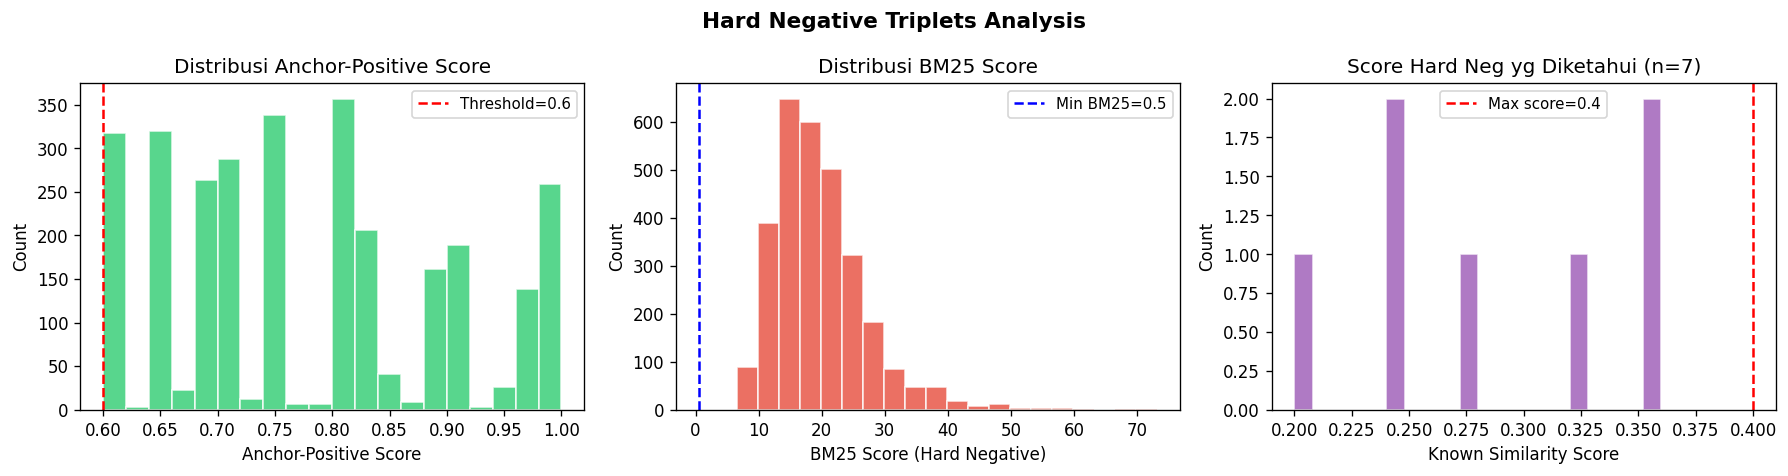


[OK] Plot tersimpan: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/evaluation/hard_negative_analysis.png


In [6]:
# ============================================================
# CELL 5.4 - Analisis Kualitas Triplets
# ============================================================
# Verifikasi kualitas triplets secara kuantitatif & kualitatif

if len(df_triplets) == 0:
    print("[ERROR] Tidak ada triplets yang ditemukan!")
    print("       Coba turunkan ANCHOR_THRESHOLD atau MIN_BM25_SCORE")
    raise ValueError("Empty triplets — adjust thresholds in CELL 5.3")

print("=" * 55)
print("  ANALISIS KUALITAS HARD NEGATIVE TRIPLETS")
print("=" * 55)

# [1] Statistik skor
print("\n[1] Distribusi anchor-positive score:")
print(df_triplets['anchor_pos_score'].describe().round(4).to_string())

print("\n[2] Distribusi BM25 score hard negatives:")
print(df_triplets['bm25_score'].describe().round(4).to_string())

# [3] Sample kualitatif
print("\n[3] Sample 5 triplets:")
print("-" * 60)
sample = df_triplets.sample(min(5, len(df_triplets)), random_state=42)
for i, (_, row) in enumerate(sample.iterrows(), 1):
    print(f"\n  Triplet {i}:")
    print(f"    Anchor   : {str(row['anchor'])[:70]}")
    print(f"    Positive : {str(row['positive'])[:70]}")
    print(f"    Hard Neg : {str(row['hard_negative'])[:70]}")
    print(f"    A-P score: {row['anchor_pos_score']:.3f}  "
          f"BM25: {row['bm25_score']:.3f}")

# [4] Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Hard Negative Triplets Analysis', fontsize=13, fontweight='bold')

# Plot 1: Distribusi anchor-positive scores
axes[0].hist(df_triplets['anchor_pos_score'], bins=20,
             color='#2ecc71', edgecolor='white', alpha=0.8)
axes[0].axvline(ANCHOR_THRESHOLD, color='red', linestyle='--',
                label=f'Threshold={ANCHOR_THRESHOLD}')
axes[0].set_xlabel('Anchor-Positive Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribusi Anchor-Positive Score')
axes[0].legend(fontsize=9)

# Plot 2: Distribusi BM25 scores
axes[1].hist(df_triplets['bm25_score'], bins=20,
             color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1].axvline(MIN_BM25_SCORE, color='blue', linestyle='--',
                label=f'Min BM25={MIN_BM25_SCORE}')
axes[1].set_xlabel('BM25 Score (Hard Negative)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribusi BM25 Score')
axes[1].legend(fontsize=9)

# Plot 3: Known neg scores (dari score_lookup)
known_mask = df_triplets['known_neg_score'] >= 0
if known_mask.sum() > 0:
    axes[2].hist(df_triplets.loc[known_mask, 'known_neg_score'],
                 bins=20, color='#9b59b6', edgecolor='white', alpha=0.8)
    axes[2].axvline(HARD_NEG_THRESHOLD, color='red', linestyle='--',
                    label=f'Max score={HARD_NEG_THRESHOLD}')
    axes[2].set_xlabel('Known Similarity Score')
    axes[2].set_ylabel('Count')
    axes[2].set_title(f'Score Hard Neg yg Diketahui (n={known_mask.sum():,})')
    axes[2].legend(fontsize=9)
else:
    axes[2].text(0.5, 0.5, 'No known scores\n(all accepted as unknown negatives)',
                 ha='center', va='center', transform=axes[2].transAxes)
    axes[2].set_title('Known Hard Neg Scores')

plt.tight_layout()
plot_path = PATHS['evaluation'] / 'hard_negative_analysis.png'
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"\n[OK] Plot tersimpan: {plot_path}")

In [7]:
# ============================================================
# CELL 5.5 - Export hard_negative_triplets.csv
# ============================================================
# File ini di-load di Stage 6 (SBERT training) via:
#   from src.data_loader import build_triplet_examples
#   triplet_examples = build_triplet_examples(PATHS['splits'] / 'hard_negative_triplets.csv')

TRIPLETS_PATH = PATHS['splits'] / 'hard_negative_triplets.csv'

# Simpan kolom yang dibutuhkan Stage 6
export_cols = ['anchor', 'positive', 'hard_negative',
               'anchor_pos_score', 'bm25_score']
df_triplets[export_cols].to_csv(TRIPLETS_PATH, index=False)

# Statistik final
hn_stats = {
    'n_triplets'         : int(len(df_triplets)),
    'n_anchor_pairs'     : int(len(df_anchors)),
    'coverage_pct'       : round(len(df_triplets)/len(df_anchors)*100, 2),
    'anchor_threshold'   : ANCHOR_THRESHOLD,
    'hard_neg_threshold' : HARD_NEG_THRESHOLD,
    'n_candidates'       : N_CANDIDATES,
    'min_bm25_score'     : MIN_BM25_SCORE,
    'corpus_size'        : len(corpus),
    'anchor_pos_score': {
        'mean' : round(float(df_triplets['anchor_pos_score'].mean()), 4),
        'min'  : round(float(df_triplets['anchor_pos_score'].min()),  4),
        'max'  : round(float(df_triplets['anchor_pos_score'].max()),  4),
    },
    'bm25_score': {
        'mean' : round(float(df_triplets['bm25_score'].mean()), 4),
        'min'  : round(float(df_triplets['bm25_score'].min()),  4),
        'max'  : round(float(df_triplets['bm25_score'].max()),  4),
    },
    'filter_stats': dict(stats),
}

stats_path = PATHS['evaluation'] / 'hard_negative_stats.json'
with open(stats_path, 'w', encoding='utf-8') as f:
    json.dump(hn_stats, f, indent=2, ensure_ascii=False)

print(f"[OK] Triplets CSV  : {TRIPLETS_PATH}")
print(f"[OK] Stats JSON    : {stats_path}")
print(f"\n{'='*55}")
print(f"  HARD NEGATIVE MINING SUMMARY")
print(f"{'='*55}")
print(f"  Total triplets     : {len(df_triplets):,}")
print(f"  Coverage           : {hn_stats['coverage_pct']:.1f}% dari anchor pairs")
print(f"  Corpus size        : {len(corpus):,} sentences")
print(f"  A-P score mean     : {hn_stats['anchor_pos_score']['mean']:.4f}")
print(f"  BM25 score mean    : {hn_stats['bm25_score']['mean']:.4f}")
print(f"{'='*55}")

[OK] Triplets CSV  : /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/datasets/splits/hard_negative_triplets.csv
[OK] Stats JSON    : /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/evaluation/hard_negative_stats.json

  HARD NEGATIVE MINING SUMMARY
  Total triplets     : 2,968
  Coverage           : 99.9% dari anchor pairs
  Corpus size        : 12,986 sentences
  A-P score mean     : 0.7783
  BM25 score mean    : 19.7724


In [8]:
# ============================================================
# CELL 5.6 - Sanity Check
# ============================================================

print("[INFO] Sanity check output Stage 5...\n")
checks = []

# [1] Triplets CSV
try:
    df_chk = pd.read_csv(TRIPLETS_PATH)
    assert len(df_chk) > 0
    assert {'anchor','positive','hard_negative'}.issubset(df_chk.columns)
    # Verifikasi: tidak ada anchor == hard_negative
    self_neg = (df_chk['anchor'] == df_chk['hard_negative']).sum()
    assert self_neg == 0, f"{self_neg} self-negatives ditemukan"
    checks.append(('hard_negative_triplets.csv', True,
                   f"{len(df_chk):,} triplets, 0 self-negatives"))
except Exception as e:
    checks.append(('hard_negative_triplets.csv', False, str(e)))

# [2] Stats JSON
try:
    s = json.load(open(stats_path))
    assert s['n_triplets'] > 0
    checks.append(('hard_negative_stats.json', True,
                   f"n_triplets={s['n_triplets']:,}"))
except Exception as e:
    checks.append(('hard_negative_stats.json', False, str(e)))

# [3] Plot
try:
    assert (PATHS['evaluation'] / 'hard_negative_analysis.png').exists()
    checks.append(('hard_negative_analysis.png', True, 'plot saved'))
except Exception as e:
    checks.append(('hard_negative_analysis.png', False, str(e)))

# [4] Validasi kolom format untuk Stage 6
try:
    df_chk = pd.read_csv(TRIPLETS_PATH)
    required = ['anchor', 'positive', 'hard_negative']
    missing  = [c for c in required if c not in df_chk.columns]
    assert len(missing) == 0, f"Kolom missing: {missing}"
    # Sample preview
    row0 = df_chk.iloc[0]
    assert len(str(row0['anchor'])) > 5
    assert len(str(row0['hard_negative'])) > 5
    checks.append(('Format untuk Stage 6', True, 'anchor/positive/hard_negative OK'))
except Exception as e:
    checks.append(('Format untuk Stage 6', False, str(e)))

# Print
print(f"  {'File':<38} {'Status':<6}  Info")
print("  " + "-" * 65)
passed = 0
for fname, ok, info in checks:
    print(f"  {fname:<38} [{'OK' if ok else 'FAIL':<4}]  {info}")
    if ok: passed += 1

print("\n  " + "-" * 65)
print(f"  Result: {'ALL PASSED' if passed==len(checks) else f'{len(checks)-passed} FAILED'}  "
      f"({passed}/{len(checks)})")

# Sample triplet final
if passed == len(checks):
    print("\n  Sample triplet (akan dipakai di Stage 6):")
    row = pd.read_csv(TRIPLETS_PATH).iloc[0]
    print(f"    Anchor   : {str(row['anchor'])[:70]}")
    print(f"    Positive : {str(row['positive'])[:70]}")
    print(f"    Hard Neg : {str(row['hard_negative'])[:70]}")

print(f"\n{'='*55}")
print(f"  Stage 5 Complete!")
print(f"  Total triplets : {len(df_triplets):,}")
print(f"  Next           : 06_sbert_training.ipynb")
print(f"{'='*55}")

[INFO] Sanity check output Stage 5...

  File                                   Status  Info
  -----------------------------------------------------------------
  hard_negative_triplets.csv             [OK  ]  2,968 triplets, 0 self-negatives
  hard_negative_stats.json               [OK  ]  n_triplets=2,968
  hard_negative_analysis.png             [OK  ]  plot saved
  Format untuk Stage 6                   [OK  ]  anchor/positive/hard_negative OK

  -----------------------------------------------------------------
  Result: ALL PASSED  (4/4)

  Sample triplet (akan dipakai di Stage 6):
    Anchor   : Pesawat terbang.
    Positive : Pesawat udara terbang.
    Hard Neg : Pesawat terbang di udara.

  Stage 5 Complete!
  Total triplets : 2,968
  Next           : 06_sbert_training.ipynb


---

## Stage 5 Complete — Output Summary

```
MyDrive/AI-Projects/sts-indonesian-embeddings/
|
+-- datasets/splits/
|   +-- hard_negative_triplets.csv   <- dipakai Stage 6 (SBERT training)
|       columns: anchor, positive, hard_negative,
|                anchor_pos_score, bm25_score
|
+-- evaluation/
    +-- hard_negative_stats.json
    +-- hard_negative_analysis.png
```

### Cara Kerja Hard Negative dalam SBERT Training
Di Stage 6, setiap triplet dikonversi ke `InputExample`:
```python
InputExample(texts=[anchor, positive, hard_negative])
```
Dengan `MultipleNegativesRankingLoss`, model dipaksa:
- **Maximize** similarity(anchor, positive)
- **Minimize** similarity(anchor, hard_negative)

Hard negative yang leksikalnya mirip tapi semantiknya beda membuat model belajar representasi yang lebih **semantik** (bukan sekadar lexical overlap).

### Estimasi Waktu Stage 5
| Sub-task | Waktu |
|----------|-------|
| Build BM25 index | < 5 detik |
| Mining (~3K anchor pairs) | ~1-2 menit |
| Analysis & export | < 30 detik |
| **Total** | **~2-3 menit** |

---
**Next:** `06_sbert_training.ipynb` — Supervised SBERT + Hard Negatives